# <font color="green">**Pitch Analysis: Coors Field vs Other MLB parks**</font>

It is well established that pitches, especially those with heavy movement, are greatly affected by the dry, thin air at altitude. This study aims to determine which pitch types are most successful at Coors Field, and which pitchers have arsenals best equipped to succeed as Colorado Rockies pitchers.

Results are demonstrated visually.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

## <font color="green">**Import date, downloaded using pybaseball**</font>

In [1]:
## map to Data

path = "data/mlb_2025_sample.csv"

In [ ]:
# Data from 2021 through 2025

df = pd.read_csv(path)

In [ ]:
df = df[['pitch_type',
         'release_speed',
         'release_pos_x',
         'release_pos_z',
         'player_name',
         'batter',
         'pitcher',
         'events',
         'description',
         'spin_dir',
         'spin_rate_deprecated',
         'break_angle_deprecated',
         'break_length_deprecated',
         'stand',
         'p_throws',
         'type',
         'bb_type',
         'pfx_x',
         'pfx_z',
         'plate_x',
         'plate_z',
         'launch_speed',
         'launch_angle',
         'release_spin_rate',
         'estimated_woba_using_speedangle',
         'home_team',
         'away_team'
]]

df['at_coors'] = (df['home_team'] == 'COL').astype(int)

## <font color="green">**Data cleaning**</font>

In [ ]:
# Remove Pitchouts, Auto-pitches, etc
df = df[~df['description'].isin(['automatic_ball', 'automatic_strike', 'pitchout', 'foul_pitchout', 'intent_ball'])]

# Remove Rare or obscure pitch types that distract from analysis
df = df[~df['pitch_type'].isin(['UN', 'SC', 'CS', 'FO','PO','EP','KN'])]


# Create Binary column for pitch success
df['pitch_success'] = (
    df['description'].isin([
        'foul','called_strike','swinging_strike',
        'foul_tip','swinging_strike_blocked','foul_bunt',
        'missed_bunt','bunt_foul_tip'
    ]) |
    ((df['description'] == 'hit_into_play') & (df['estimated_woba_using_speedangle'] >= .100))
).astype(int)

## <font color="green">**Visualizing Pitch Success Rate - All pitchers**</font>

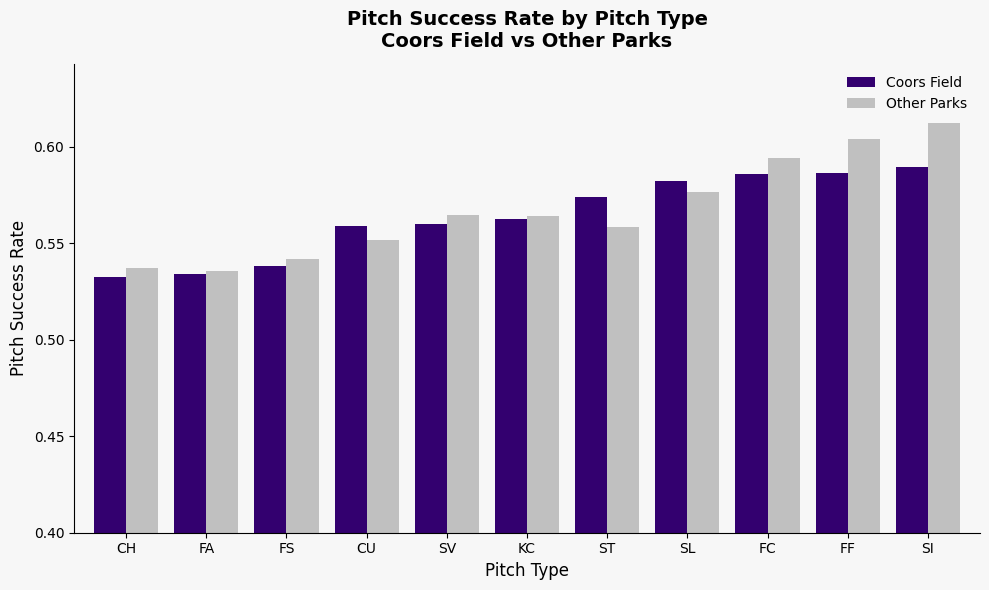

In [ ]:
# Okay lets have some fun!

import seaborn as sns
import matplotlib.pyplot as plt

# Compute pitch success rate per pitch type, split by at_coors
success_rates = df.groupby(['pitch_type', 'at_coors'])['pitch_success'].mean().reset_index()

# Map at_coors to labels
success_rates['park'] = success_rates['at_coors'].map({1: 'Coors Field', 0: 'Other Parks'})

# Determine order of pitch types by Coors success rate
coors_order = success_rates[success_rates['park'] == 'Coors Field'].sort_values('pitch_success')['pitch_type']

# Pivot table for plotting
plot_df = success_rates.pivot(index='pitch_type', columns='park', values='pitch_success').reindex(coors_order)

# Colors
coors_color = "#33006F"   # Rockies purple
other_color = "#C0C0C0"   # soft gray

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='bar', ax=ax, color=[coors_color, other_color], width=0.8)

# Background and style
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#F7F7F7")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Labels and title
ax.set_title(
    "Pitch Success Rate by Pitch Type\nCoors Field vs Other Parks",
    fontsize=14, weight="bold", pad=12
)
ax.set_xlabel("Pitch Type", fontsize=12)
ax.set_ylabel("Pitch Success Rate", fontsize=12)
ax.set_ylim(0.4, ax.get_ylim()[1])

ax.yaxis.grid(True, linestyle="", alpha=0.4)
ax.xaxis.grid(False)
ax.legend(title="", frameon=False)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## <font color="green">**Visualizing Pitch Success Rate Differential - All pitchers**</font>

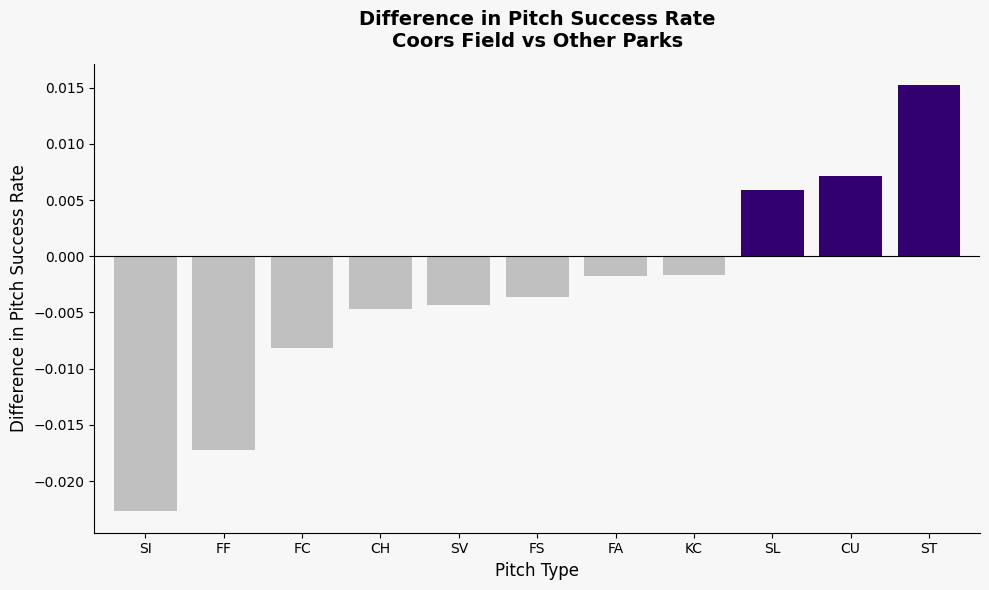

In [ ]:

# Compute pitch success rate per pitch type, split by at_coors
success_rates = df.groupby(['pitch_type', 'at_coors'])['pitch_success'].mean().reset_index()
success_rates['park'] = success_rates['at_coors'].map({1: 'Coors Field', 0: 'Other Parks'})

# Pivot table: rows=pitch_type, columns=park
plot_df = success_rates.pivot(index='pitch_type', columns='park', values='pitch_success')

# Compute delta: Coors Field minus Other Parks
plot_df['delta'] = plot_df['Coors Field'] - plot_df['Other Parks']

# Sort by delta ascending or descending
plot_df = plot_df.sort_values('delta', ascending=True)

# Colors for delta bars
delta_color = "#33006F"  # purple for positive delta
neg_color = "#C0C0C0"    # gray for negative delta
bar_colors = [delta_color if v >= 0 else neg_color for v in plot_df['delta']]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
plot_df['delta'].plot(kind='bar', ax=ax, color=bar_colors, width=0.8)

# Background and style
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#F7F7F7")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Labels and title
ax.set_title(
    "Difference in Pitch Success Rate\nCoors Field vs Other Parks",
    fontsize=14, weight="bold", pad=12
)
ax.set_xlabel("Pitch Type", fontsize=12)
ax.set_ylabel("Difference in Pitch Success Rate", fontsize=12)
ax.axhline(0, color='black', linewidth=0.8)  # zero line
ax.yaxis.grid(True, linestyle="", alpha=0.4)
ax.xaxis.grid(False)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## <font color="green">**Determine pitchers that have the highest 'Pitch Success Rate' at Coors Field**</font>

In [ ]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 98.1 MB/s eta 0:00:00


In [ ]:
from pybaseball import playerid_reverse_lookup


# Get unique pitcher IDs
pitcher_ids = df['pitcher'].unique().tolist()

# Look up names for those IDs
player_lookup_df = playerid_reverse_lookup(pitcher_ids, key_type='mlbam')

# Merge first and last names directly into df
df = df.merge(
    player_lookup_df[['key_mlbam', 'name_first', 'name_last']],
    left_on='pitcher',
    right_on='key_mlbam',
    how='left'
)

# Create full name column
df['pitcher_name'] = df['name_first'] + ' ' + df['name_last']

Gathering player lookup table. This may take a moment.


In [ ]:
df.head(100)

,pitch_type,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,...,release_spin_rate,estimated_woba_using_speedangle,home_team,away_team,at_coors,pitch_success,key_mlbam,name_first,name_last,pitcher_name
0,SI,94.4,-0.97,5.85,"Graveman, Kendall",624585,608665,strikeout,swinging_strike,NaN,...,2244.0,0.000,ATL,HOU,0,1,608665.0,kendall,graveman,kendall graveman
1,SI,95.7,-1.06,5.85,"Graveman, Kendall",624585,608665,NaN,foul,NaN,...,2135.0,NaN,ATL,HOU,0,1,608665.0,kendall,graveman,kendall graveman
2,SI,96.6,-0.89,5.90,"Graveman, Kendall",624585,608665,NaN,ball,NaN,...,2214.0,NaN,ATL,HOU,0,0,608665.0,kendall,graveman,kendall graveman
3,SI,95.4,-1.02,5.88,"Graveman, Kendall",624585,608665,NaN,foul,NaN,...,2260.0,NaN,ATL,HOU,0,1,608665.0,kendall,graveman,kendall graveman
4,SI,96.0,-1.08,5.82,"Graveman, Kendall",624585,608665,NaN,called_strike,NaN,...,2190.0,NaN,ATL,HOU,0,1,608665.0,kendall,graveman,kendall graveman
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,KC,77.0,2.07,6.71,"Smyly, Drew",493329,592767,NaN,ball,NaN,...,2089.0,NaN,ATL,HOU,0,0,592767.0,drew,smyly,drew smyly
96,KC,75.8,1.99,6.70,"Smyly, Drew",493329,592767,NaN,called_strike,NaN,...,1978.0,NaN,ATL,HOU,0,1,592767.0,drew,smyly,drew smyly
97,KC,76.4,2.04,6.66,"Smyly, Drew",493329,592767,NaN,ball,NaN,...,1952.0,NaN,ATL,HOU,0,0,592767.0,drew,smyly,drew smyly
98,FF,91.1,-1.42,5.42,"Maton, Phil",592626,664208,field_out,hit_into_play,NaN,...,2542.0,0.003,ATL,HOU,0,0,664208.0,phil,maton,phil maton


In [ ]:
coors_df = df[df['at_coors'] == 1]

pitch_counts = coors_df['pitcher_name'].value_counts()

eligible_pitchers = pitch_counts[pitch_counts > 500].index
coors_df_filtered = coors_df[coors_df['pitcher_name'].isin(eligible_pitchers)]

pitcher_success = coors_df_filtered.groupby('pitcher_name')['pitch_success'].mean().reset_index()

pitcher_success = pitcher_success.sort_values('pitch_success', ascending=False)

# Take top 25
top_pitchers = pitcher_success.head(25)
print(top_pitchers)

         pitcher_name  pitch_success
35      tanner gordon       0.623794
40         zac gallen       0.620192
29      merrill kelly       0.606154
36           ty blach       0.596260
33  robert stephenson       0.596197
26      kyle freeland       0.595902
21       jimmy herget       0.591340
27         logan webb       0.591292
32     pierce johnson       0.590980
18          jake bird       0.586996
5         brent suter       0.584488
13     connor seabold       0.584318
37       tyler kinley       0.583663
3       austin gomber       0.580338
1      anthony molina       0.576844
17     germán márquez       0.575657
11   chi chi gonzález       0.574324
24         juan mejia       0.571936
15        daniel bard       0.570953
30         nick mears       0.568783
22           jon gray       0.568134
25    justin lawrence       0.567679
2   antonio senzatela       0.565444
0      angel chivilli       0.565410
34       ryan feltner       0.565364


## <font color="green">**Visualize pitch success rates by pitch type for selected pitcher**</font>

In [ ]:

def plot_pitch_success_by_pitcher(player_name, df):
    """
    Plot pitch success rate by pitch type for a single pitcher,
    split by Coors Field vs Other Parks.

    Parameters:
        player_name (str): Full name of pitcher, e.g., "German Marquez"
        df (pd.DataFrame): Dataframe with columns 'pitch_type', 'pitch_success', 'at_coors', 'pitcher_name'
    """
    # Filter to the selected pitcher
    pitcher_df = df[df['pitcher_name'] == player_name]

    if pitcher_df.empty:
        print(f"No data found for pitcher: {player_name}")
        return

    # Compute pitch success rate per pitch type, split by at_coors
    success_rates = pitcher_df.groupby(['pitch_type', 'at_coors'])['pitch_success'].mean().reset_index()

    # Map at_coors to labels
    success_rates['park'] = success_rates['at_coors'].map({1: 'Coors Field', 0: 'Other Parks'})

    # Determine order of pitch types by Coors success rate
    coors_order = success_rates[success_rates['park'] == 'Coors Field'].sort_values('pitch_success')['pitch_type']

    # Pivot table for plotting
    plot_df = success_rates.pivot(index='pitch_type', columns='park', values='pitch_success').reindex(coors_order)

    # Colors
    coors_color = "#33006F"   # Rockies purple
    other_color = "#C0C0C0"   # soft gray

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df.plot(kind='bar', ax=ax, color=[coors_color, other_color], width=0.8)

    # Background and style
    ax.set_facecolor("#F7F7F7")
    fig.patch.set_facecolor("#F7F7F7")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Labels and title
    ax.set_title(
        f"Pitch Success Rate by Pitch Type\n{player_name}: Coors Field vs Other Parks",
        fontsize=14, weight="bold", pad=12
    )
    ax.set_xlabel("Pitch Type", fontsize=12)
    ax.set_ylabel("Pitch Success Rate", fontsize=12)
    ax.set_ylim(0.4, ax.get_ylim()[1])

    ax.yaxis.grid(True, linestyle="", alpha=0.4)
    ax.xaxis.grid(False)
    ax.legend(title="", frameon=False)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

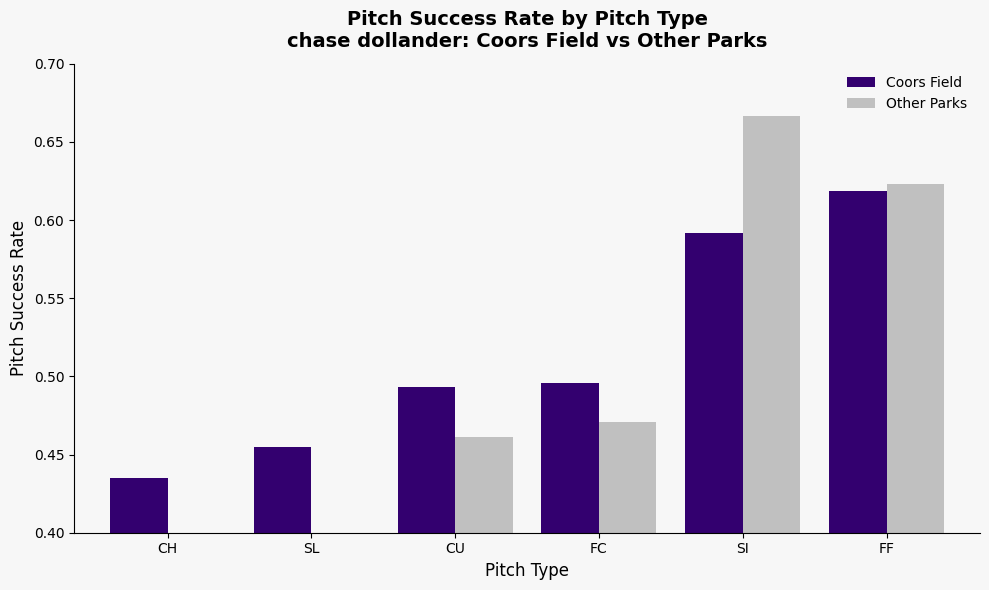

In [ ]:
plot_pitch_success_by_pitcher("chase dollander", df)

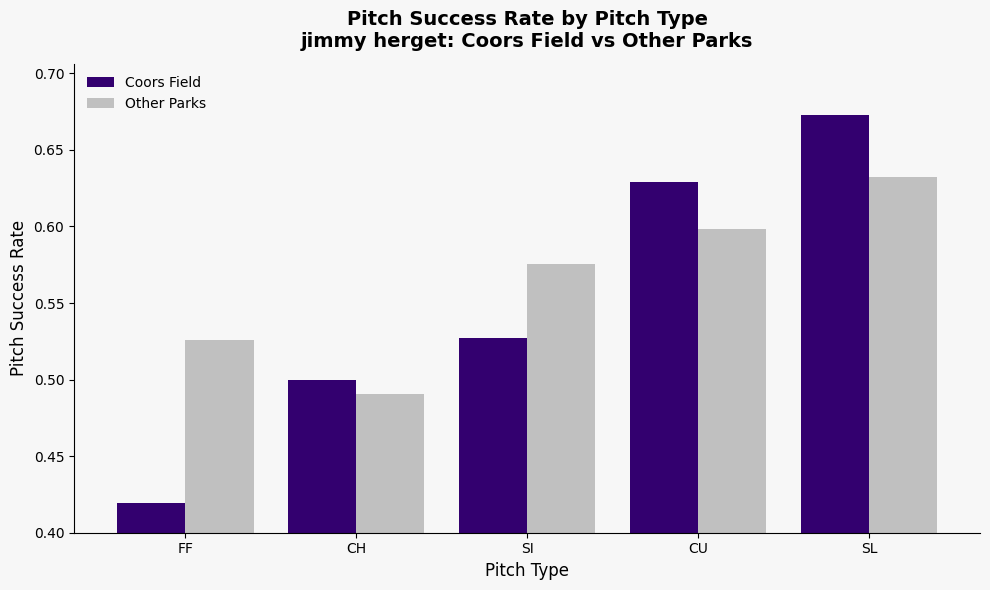

In [ ]:
plot_pitch_success_by_pitcher("jimmy herget", df)

## <font color="green">**Visualize pitch success rate differential by pitch type for selected pitcher**</font>

In [ ]:
import matplotlib.pyplot as plt

def plot_pitch_success_delta(player_name, df, min_pitches=10):
    """
    Plot difference in pitch success rate (Coors Field - Other Parks)
    for an individual pitcher.
    """

    pitcher_df = df[df['pitcher_name'] == player_name].copy()

    if pitcher_df.empty:
        print(f"No data for {player_name}")
        return

    # Optional pitch count filter
    pitch_counts = pitcher_df['pitch_type'].value_counts()
    valid_pitches = pitch_counts[pitch_counts >= min_pitches].index
    pitcher_df = pitcher_df[pitcher_df['pitch_type'].isin(valid_pitches)]

    # Compute success rates
    success_rates = (
        pitcher_df
        .groupby(['pitch_type', 'at_coors'])['pitch_success']
        .mean()
        .reset_index()
    )

    success_rates['park'] = success_rates['at_coors'].map({
        1: 'Coors Field',
        0: 'Other Parks'
    })

    plot_df = success_rates.pivot(
        index='pitch_type',
        columns='park',
        values='pitch_success'
    )

    # Require both parks
    plot_df = plot_df.dropna()

    if plot_df.empty:
        print(f"Not enough Coors vs Other data for {player_name}")
        return

    plot_df['delta'] = plot_df['Coors Field'] - plot_df['Other Parks']
    plot_df = plot_df.sort_values('delta', ascending=True)

    delta_color = "#33006F"
    neg_color = "#C0C0C0"
    bar_colors = [
        delta_color if v >= 0 else neg_color
        for v in plot_df['delta']
    ]

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df['delta'].plot(
        kind='bar',
        ax=ax,
        color=bar_colors,
        width=0.8
    )

    ax.set_facecolor("#F7F7F7")
    fig.patch.set_facecolor("#F7F7F7")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(
        f"Difference in Pitch Success Rate\nCoors Field vs Other Parks — {player_name}",
        fontsize=14,
        weight="bold",
        pad=12
    )

    ax.set_xlabel("Pitch Type", fontsize=12)
    ax.set_ylabel("Difference in Pitch Success Rate", fontsize=12)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.yaxis.grid(True, linestyle="", alpha=0.4)
    ax.xaxis.grid(False)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

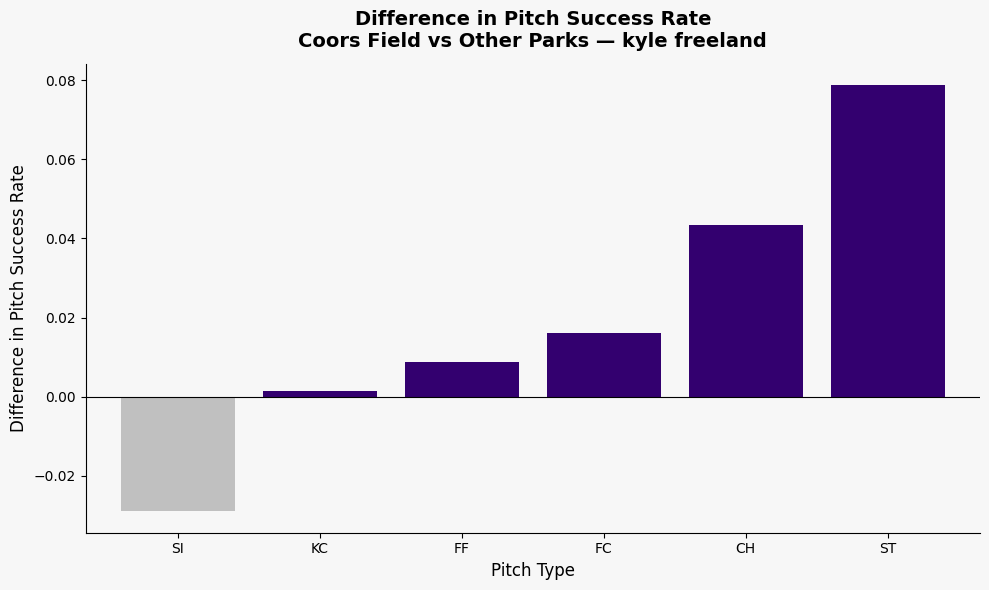

In [ ]:
plot_pitch_success_delta("kyle freeland", df)

## <font color="green">**Visualize pitch movement profiles on the road vs at Coors Field for selected pitcher**</font>

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Patch
import numpy as np

def plot_pitch_movement_profile(player_name, df, radius=27):
    """
    Plot Savant-style mean ± SD pitch movement for a pitcher,
    differentiating Coors Field (hatched, no fill) vs Other Parks (filled ellipse).
    """

    pitcher_df = df[df['pitcher_name'] == player_name].copy()
    if pitcher_df.empty:
        print(f"No data for {player_name}")
        return

    # Flip horizontal axis to match Savant orientation, convert to inches
    pitcher_df['pfx_x_plot'] = -pitcher_df['pfx_x'] * 12
    pitcher_df['pfx_z_plot'] = pitcher_df['pfx_z'] * 12

    # Vibrant pitch colors
    pitch_colors = {
        'FF': '#FF2D2D', 'SI': '#FF7F0E', 'FC': '#FFD700', 'SL': '#1F77FF',
        'CU': '#00B050', 'CH': '#00CFFF', 'KC': '#8A2BE2', 'FS': '#FF1493',
        'ST': '#8B4513', 'SV': '#7F7F7F'
    }

    fig, ax = plt.subplots(figsize=(9,9))
    subtle_purple = (0.95, 0.90, 1.0, 0.15)  # RGBA tuple: R,G,B in 0-1, alpha last

    fig.patch.set_facecolor(subtle_purple)
    ax.set_facecolor(subtle_purple)

    # Keep track of legend handles for pitch types
    pitch_handles = {}

    # Loop through pitch types and park
    for (pitch, park), group in pitcher_df.groupby(['pitch_type', 'at_coors']):

        if len(group) < 5:
            continue

        color = pitch_colors.get(pitch, 'gray')
        mean_x = group['pfx_x_plot'].mean()
        mean_z = group['pfx_z_plot'].mean()
        std_x = group['pfx_x_plot'].std()
        std_z = group['pfx_z_plot'].std()

        # Ellipse style
        if park == 1:  # Coors Field
            facecolor = 'none'      # no fill
            hatch_pattern = '///'
        else:          # Other Parks
            facecolor = color       # filled
            hatch_pattern = None

        ellipse = Ellipse(
            (mean_x, mean_z),
            width=3*std_x,
            height=3*std_z,
            facecolor=facecolor,
            edgecolor=color,
            alpha=0.5,
            hatch=hatch_pattern,
            linewidth=2
        )
        ax.add_patch(ellipse)

        # Mean point (always circle)
        if park == 1:  # Coors Field
          point_facecolor = 'white'
        else:
          point_facecolor = color

        ax.scatter(mean_x, mean_z,
                   color=point_facecolor,
                   edgecolor='black',
                   s=120,
                   marker='o')

        # Save one handle per pitch type for legend
        if pitch not in pitch_handles:
            pitch_handles[pitch] = Patch(facecolor=color, edgecolor='black', label=pitch)

    # Circular grid
    for r in range(5, radius+1, 5):
        circle = plt.Circle((0,0), r, color='gray', fill=False, linestyle='--', alpha=0.6)
        ax.add_artist(circle)

    ax.axhline(0, linewidth=1, alpha=0.6)
    ax.axvline(0, linewidth=1, alpha=0.6)

    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel("Horizontal Movement (inches)")
    ax.set_ylabel("Vertical Movement (inches)")
    ax.set_title(f"Pitch Movement Profile: {player_name}",
                 fontsize=14, weight='bold')

    # Create combined legend
    park_patches = [
        Patch(facecolor='white', edgecolor='black', hatch='///', label='Coors Field'),
        Patch(facecolor='black', edgecolor='black', alpha=0.5, label='Other Parks')
    ]

    combined_handles = list(pitch_handles.values()) + [
        Patch(facecolor='white', edgecolor='black', hatch='///', label='Coors Field'),
        Patch(facecolor='gray', edgecolor='black', alpha=0.5, label='Other Parks')
    ]

    ax.legend(handles=combined_handles, title="Pitch Type & Park", frameon=False, bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()



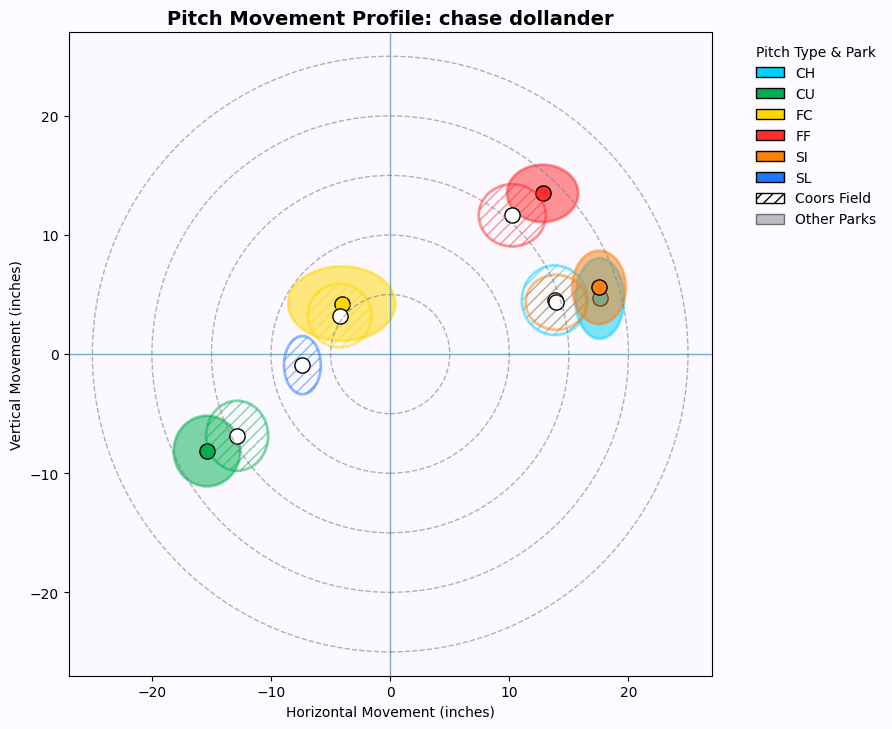

In [ ]:
plot_pitch_movement_profile('chase dollander', df)

## <font color="green">**Visualize pitch movement profiles on the road vs at Coors Field for every pitcher**</font>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse, Patch

def plot_pitch_movement_profile_avg(throw_hand, df, radius=27):
    """
    Plot combined Savant-style mean ± SD pitch movement for ALL pitchers
    of a given throwing hand ('R' or 'L'),
    differentiating Coors Field vs Other Parks.
    """

    pitcher_df = df[df['p_throws'] == throw_hand].copy()
    if pitcher_df.empty:
        print(f"No data for throwing hand: {throw_hand}")
        return

    # Flip horizontal axis to match Savant orientation, convert to inches
    pitcher_df['pfx_x_plot'] = -pitcher_df['pfx_x'] * 12
    pitcher_df['pfx_z_plot'] = pitcher_df['pfx_z'] * 12

    pitch_colors = {
        'FF': '#FF2D2D', 'SI': '#FF7F0E', 'FC': '#FFD700', 'SL': '#1F77FF',
        'CU': '#00B050', 'CH': '#00CFFF', 'KC': '#8A2BE2', 'FS': '#FF1493',
        'ST': '#8B4513', 'SV': '#7F7F7F'
    }

    fig, ax = plt.subplots(figsize=(9,9))
    subtle_purple = (0.95, 0.90, 1.0, 0.15)
    fig.patch.set_facecolor(subtle_purple)
    ax.set_facecolor(subtle_purple)

    pitch_handles = {}

    for (pitch, park), group in pitcher_df.groupby(['pitch_type', 'at_coors']):

        if len(group) < 20:   # increase threshold since now aggregated
            continue

        color = pitch_colors.get(pitch, 'gray')

        mean_x = group['pfx_x_plot'].mean()
        mean_z = group['pfx_z_plot'].mean()
        std_x = group['pfx_x_plot'].std()
        std_z = group['pfx_z_plot'].std()

        if park == 1:
            facecolor = 'none'
            hatch_pattern = '///'
        else:
            facecolor = color
            hatch_pattern = None

        ellipse = Ellipse(
            (mean_x, mean_z),
            width=2*std_x,
            height=2*std_z,
            facecolor=facecolor,
            edgecolor=color,
            alpha=0.5,
            hatch=hatch_pattern,
            linewidth=2
        )
        ax.add_patch(ellipse)

        if park == 1:
            point_facecolor = 'white'
        else:
            point_facecolor = color

        ax.scatter(mean_x, mean_z,
                   color=point_facecolor,
                   edgecolor='black',
                   s=120,
                   marker='o')

        if pitch not in pitch_handles:
            pitch_handles[pitch] = Patch(facecolor=color, edgecolor='black', label=pitch)

    # Circular grid
    for r in range(5, radius+1, 5):
        circle = plt.Circle((0,0), r, color='gray',
                            fill=False, linestyle='--', alpha=0.6)
        ax.add_artist(circle)

    ax.axhline(0, linewidth=1, alpha=0.6)
    ax.axvline(0, linewidth=1, alpha=0.6)

    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)
    ax.set_aspect('equal', adjustable='box')

    hand_label = "Right-Handed Pitchers" if throw_hand == 'R' else "Left-Handed Pitchers"

    ax.set_xlabel("Horizontal Movement (inches)")
    ax.set_ylabel("Vertical Movement (inches)")
    ax.set_title(f"Pitch Movement Profile: {hand_label}",
                 fontsize=14, weight='bold')

    combined_handles = list(pitch_handles.values()) + [
        Patch(facecolor='white', edgecolor='black', hatch='///', label='Coors Field'),
        Patch(facecolor='gray', edgecolor='black', alpha=0.5, label='Other Parks')
    ]

    ax.legend(handles=combined_handles,
              title="Pitch Type & Park",
              frameon=False,
              bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()

In [ ]:
df_select = df[df['pitch_type'].isin(['SI', 'FF', 'FC', 'SL','CU','ST'])]

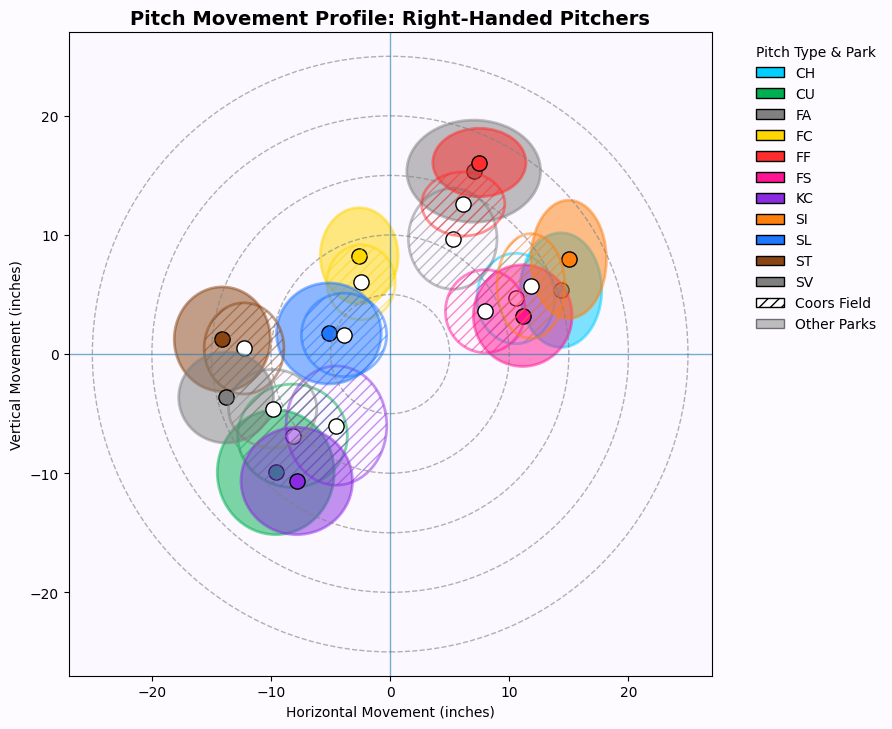

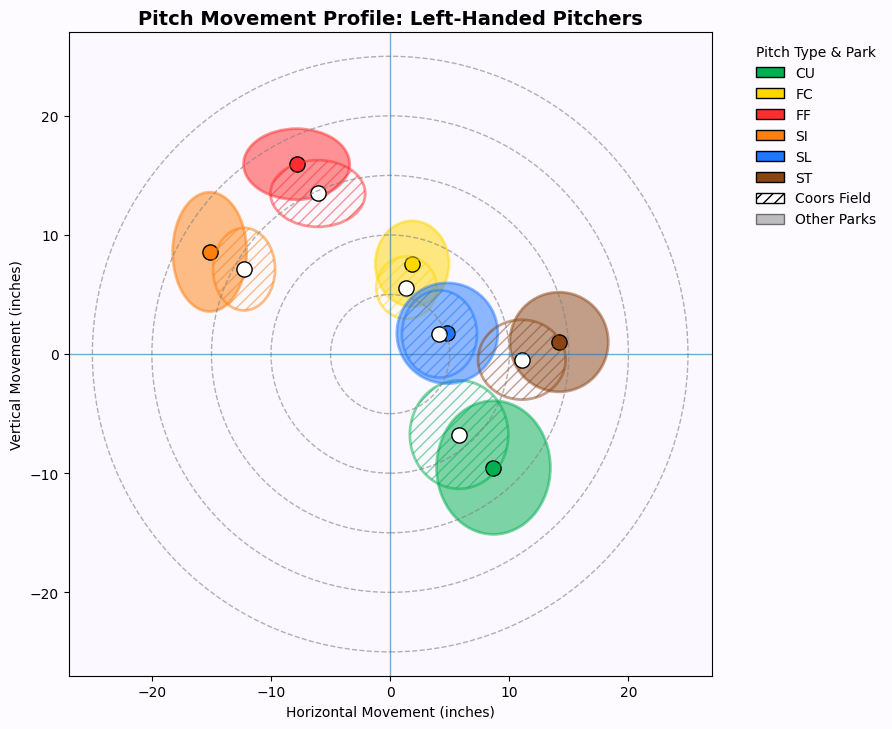

In [ ]:
plot_pitch_movement_profile_avg('R', df)
plot_pitch_movement_profile_avg('L', df_select)

## <font color="green">**Determine the Euclidiean distance differential for pitch movement on the road vs at Coors Field for selected pitcher**</font>

In [ ]:
import pandas as pd
import numpy as np

def pitch_movement_delta(player_name, df):
    """
    Compute Euclidean distance between mean pfx_x / pfx_z at Coors vs Other Parks
    for each pitch type for a given pitcher.

    Returns a DataFrame with pitch_type, coors_mean_x, coors_mean_z, other_mean_x,
    other_mean_z, and euclidean_delta.
    """

    pitcher_df = df[df['pitcher_name'] == player_name].copy()
    if pitcher_df.empty:
        print(f"No data for {player_name}")
        return None

    # Convert to inches and flip horizontal to match Savant orientation
    pitcher_df['pfx_x_plot'] = -pitcher_df['pfx_x'] * 12
    pitcher_df['pfx_z_plot'] = pitcher_df['pfx_z'] * 12

    results = []

    for pitch, group in pitcher_df.groupby('pitch_type'):
        coors = group[group['at_coors'] == 1]
        other = group[group['at_coors'] == 0]

        if len(coors) < 5 or len(other) < 5:
            continue  # skip if not enough samples

        coors_mean_x = coors['pfx_x_plot'].mean()
        coors_mean_z = coors['pfx_z_plot'].mean()

        other_mean_x = other['pfx_x_plot'].mean()
        other_mean_z = other['pfx_z_plot'].mean()

        euclidean_delta = np.sqrt(
            (coors_mean_x - other_mean_x)**2 + (coors_mean_z - other_mean_z)**2
        )

        results.append({
            'pitch_type': pitch,
            'coors_mean_x': coors_mean_x,
            'coors_mean_z': coors_mean_z,
            'other_mean_x': other_mean_x,
            'other_mean_z': other_mean_z,
            'euclidean_delta': euclidean_delta
        })

    return pd.DataFrame(results).sort_values('euclidean_delta', ascending=False)

In [ ]:
pitch_movement_delta("dylan cease", df)

,pitch_type,coors_mean_x,coors_mean_z,other_mean_x,other_mean_z,euclidean_delta
2,FF,2.141443,14.967216,3.406092,18.768039,4.005695
4,SI,8.448000,12.300000,10.684110,14.947397,3.465386
3,KC,-4.618868,-13.702642,-3.822327,-16.746467,3.146324
0,CH,5.040000,15.413333,7.354661,15.816630,2.349533
6,ST,-9.678462,-7.966154,-11.421290,-9.384194,2.246840
1,FC,-3.360000,4.608000,-2.828571,6.694286,2.152906
5,SL,-2.772834,0.377326,-3.126021,1.523030,1.198907


## <font color="green">**Determine the average MLB wide Euclidiean distance differential for pitch movement on the road vs at Coors Field - Seperated by handedness**</font>

In [ ]:
import pandas as pd
import numpy as np

def league_pitch_movement_delta_by_hand(df, hand_col='p_throws', min_samples=20):
    """
    Compute average Euclidean distance between mean pitch movement at Coors vs Other Parks
    per pitch type across ALL pitchers, separated by handedness.

    Returns:
        DataFrame with handedness, pitch_type, and euclidean_delta
    """

    data = df.copy()

    # Convert to inches and match Savant orientation
    data['pfx_x_plot'] = -data['pfx_x'] * 12
    data['pfx_z_plot'] = data['pfx_z'] * 12

    results = []

    for hand, hand_group in data.groupby(hand_col):

        for pitch, group in hand_group.groupby('pitch_type'):

            coors = group[group['at_coors'] == 1]
            other = group[group['at_coors'] == 0]

            if len(coors) < min_samples or len(other) < min_samples:
                continue

            coors_mean_x = coors['pfx_x_plot'].mean()
            coors_mean_z = coors['pfx_z_plot'].mean()

            other_mean_x = other['pfx_x_plot'].mean()
            other_mean_z = other['pfx_z_plot'].mean()

            euclidean_delta = np.sqrt(
                (coors_mean_x - other_mean_x)**2 +
                (coors_mean_z - other_mean_z)**2
            )

            results.append({
                'handedness': hand,
                'pitch_type': pitch,
                'coors_mean_x': coors_mean_x,
                'coors_mean_z': coors_mean_z,
                'other_mean_x': other_mean_x,
                'other_mean_z': other_mean_z,
                'euclidean_delta': euclidean_delta
            })

    return pd.DataFrame(results).sort_values(
        ['handedness', 'euclidean_delta'],
        ascending=[True, False]
    )

In [ ]:
league_pitch_movement_delta_by_hand(df)

,handedness,pitch_type,coors_mean_x,coors_mean_z,other_mean_x,other_mean_z,euclidean_delta
4,L,FS,-4.949752,4.836694,-9.119902,5.659588,4.250565
1,L,CU,5.786777,-6.757969,8.671519,-9.525802,3.997829
0,L,CH,-10.661622,6.005382,-14.251080,6.430949,3.614598
8,L,ST,11.054333,-0.467166,14.181133,1.014205,3.459963
6,L,SI,-12.266113,7.131020,-15.151527,8.580716,3.229122
9,L,SV,10.592627,-3.076313,13.653556,-3.486139,3.088243
3,L,FF,-6.071081,13.483498,-7.854035,15.943946,3.038540
2,L,FC,1.372126,5.575798,1.844947,7.585983,2.065043
5,L,KC,3.456621,-7.540645,3.029749,-6.926279,0.748108
7,L,SL,4.137778,1.690839,4.798319,1.750132,0.663197
